# **Credit Card Fraud Detection**

# **Probem Understanding**
1. Problem: Check the Transaction is fraudulent or not.

2. Target: Class = 1 (FRAUDULENT) & Class = 0 (NOT FRAUDULENT)

3. Business goal: Reduce Fraud Credit Card Transaction

#**Importing Libraries**

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Load Dataset & Basic Info

In [49]:
df = pd.read_csv('creditcard.csv')

In [50]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [51]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [52]:
df.shape

(284807, 31)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#**Data Cleaning**

In [54]:
df.isnull().sum().sum()

np.int64(0)

In [55]:
df.duplicated().sum()

np.int64(1081)

In [56]:
df.dtypes.value_counts()

,count
float64,30
int64,1


In [57]:
df[df.duplicated(keep=False)].sort_values(by='Time').head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
222,145.0,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0


In [58]:
df[df.duplicated(keep=False)].shape

(1854, 31)

In [59]:
df[df.duplicated(keep=False)]['Class'].value_counts()

,count
Class,
0,1822
1,32


In [60]:
df = df.drop_duplicates().reset_index(drop=True)

In [61]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (283726, 31)
Duplicates: 0


#**EDA (Exploratory Data Analysis)**

In [62]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


In [63]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.83329
1,0.16671


#**Target distribution**

#Numerical Feature

In [64]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


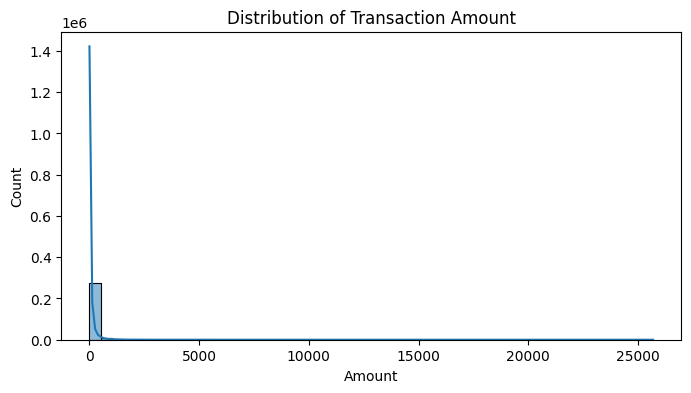

In [65]:
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.show()

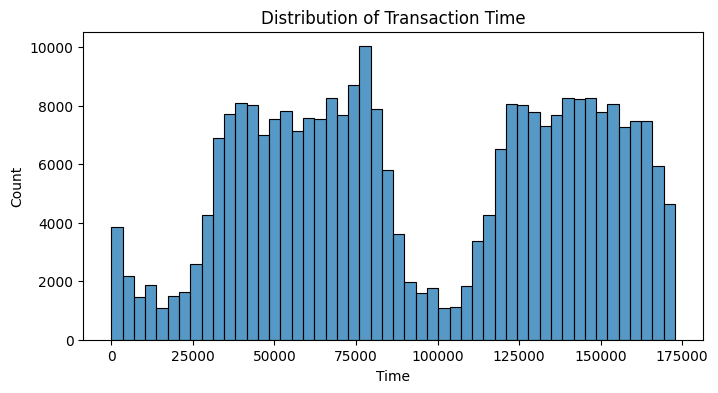

In [66]:
plt.figure(figsize=(8,4))
sns.histplot(df['Time'], bins=50)
plt.title('Distribution of Transaction Time')
plt.xlabel('Time')
plt.show()

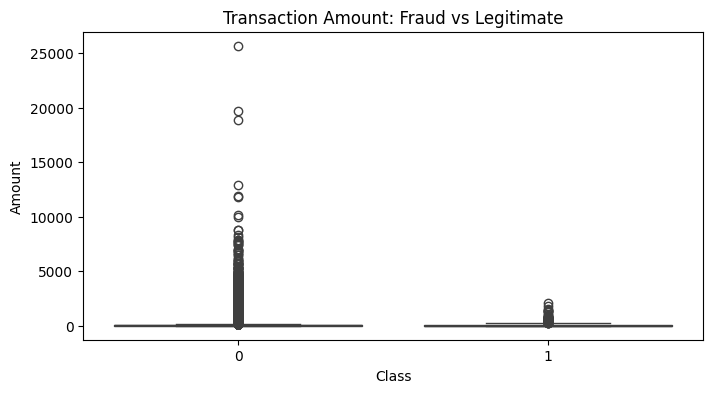

In [67]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.show()

In [68]:
df.groupby('Class')['Amount'].agg(['mean', 'median', 'std'])

,mean,median,std
Class,,,
0,88.413575,22.00,250.379023
1,123.871860,9.82,260.211041


# In this dataset, fraudulent transactions appear to be concentrated in lower transaction amounts, while legitimate transactions include a much wider range of amounts, including very high-value transactions.

In [69]:
df.groupby('Class')['Time'].agg(['mean', 'median', 'std'])

,mean,median,std
Class,,,
0,94835.058093,84711.0,47475.550607
1,80450.513742,73408.0,48636.179973


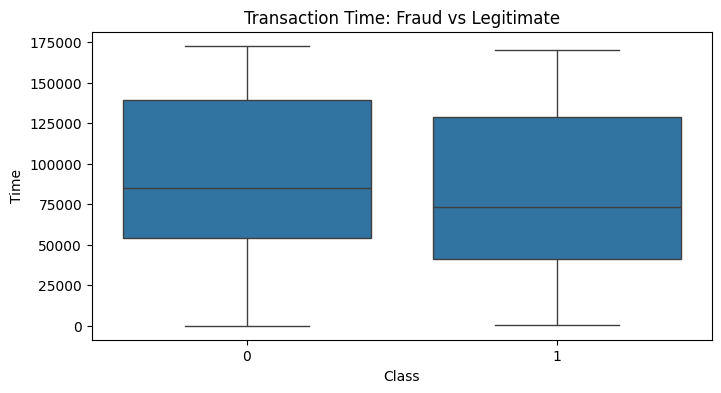

In [70]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Time', data=df)
plt.title('Transaction Time: Fraud vs Legitimate')
plt.show()

# Fraudulent transactions tend to occur earlier in the observed time period than legitimate transactions. However, the distributions still overlap considerably, so Time alone is not sufficient to identify fraud.

In [71]:
corr = df.corr(numeric_only=True)['Class'].sort_values(ascending=False)

corr.head(10), corr.tail(10)

(Class    1.000000
 V11      0.149067
 V4       0.129326
 V2       0.084624
 V19      0.033631
 V8       0.033068
 V21      0.026357
 V27      0.021892
 V20      0.021486
 V28      0.009682
 Name: Class, dtype: float64,
 V9    -0.094021
 V1    -0.094486
 V18   -0.105340
 V7    -0.172347
 V3    -0.182322
 V16   -0.187186
 V10   -0.206971
 V12   -0.250711
 V14   -0.293375
 V17   -0.313498
 Name: Class, dtype: float64)

#**Feature Engineering**

In [72]:
#AMount - highly right skewed so use LOG TRANSFORMATION

df['Amount_log'] = np.log1p(df['Amount'])

In [73]:
df[['Amount', 'Amount_log']].describe()

,Amount,Amount_log
count,283726.000000,283726.000000
mean,88.472687,3.153760
std,250.399437,1.657080
min,0.000000,0.000000
25%,5.600000,1.887070
50%,22.000000,3.135494
75%,77.510000,4.363226
max,25691.160000,10.153941


#**Feature Selection**

In [74]:
nunique = df.drop(columns=['Class']).nunique().sort_values()
nunique.head(15)

,0
Amount_log,32767
Amount,32767
Time,124592
V1,275663
V4,275663
V5,275663
V2,275663
V3,275663
V8,275663
V9,275663


In [75]:
corr_matrix = df.drop(columns='Class').corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

high_corr

[]

In [76]:
target_corr = (
    df.corr(numeric_only=True)['Class']
    .drop('Class')
    .abs()
    .sort_values(ascending=False)
)

target_corr.head(15)

,Class
V17,0.313498
V14,0.293375
V12,0.250711
V10,0.206971
V16,0.187186
V3,0.182322
V7,0.172347
V11,0.149067
V4,0.129326
V18,0.105340


# Feature selection based on simple statistical checks: no major features removed.

# **Train-Test-Split**

In [77]:
X = df.drop(columns='Class')
y = df['Class']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.0016653449643140364
Test fraud rate: 0.0016741268107003137


# **PREPROCESSING & SCALING**

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (226980, 31)
Test shape: (56746, 31)


# **BASELINE MODEL**

“Complex models use karne se pehle ek simple model kitna perform karta hai?”

# **Logistic Regression**

In [82]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_LR.fit(X_train_scaled, y_train)

y_pred_LR = model_LR.predict(X_test_scaled)

In [83]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))

[[56641    10]
 [   39    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



**Logistic Regression performed well in terms of precision but detected only 59% of actual fraudulent transactions. Therefore, accuracy alone is not an appropriate metric for this highly imbalanced dataset, and improving fraud recall will be an important objective for the next models.**

# **Random Forest**

In [84]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model_RF.fit(X_train, y_train)

y_pred_RF = model_RF.predict(X_test)

In [85]:
print(confusion_matrix(y_test, y_pred_RF))
print(classification_report(y_test, y_pred_RF))

[[56650     1]
 [   29    66]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



**Random Forest performed better than Logistic Regression on the minority fraud class. It increased recall from 59% to 69% and F1-score from 70% to 81%, while also reducing false positives from 10 to 1. This suggests that the non-linear relationships captured by Random Forest are more useful for this fraud detection problem.**

#**Boosting**

**XGBOOST**

In [86]:
from xgboost import XGBClassifier
#Class Ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative: 226602
Positive: 378
scale_pos_weight: 599.4761904761905


In [87]:
model_XGB = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_XGB.fit(X_train, y_train)

y_pred_XGB = model_XGB.predict(X_test)

In [88]:
print(confusion_matrix(y_test, y_pred_XGB))
print(classification_report(y_test, y_pred_XGB))

[[56608    43]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.64      0.79      0.70        95

    accuracy                           1.00     56746
   macro avg       0.82      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746



**XGBoost achieved the highest fraud recall among the tested models, detecting 79% of actual fraud cases. However, its precision was lower than Random Forest, resulting in more false positives. Therefore, model selection should consider the business cost of false negatives versus false positives rather than accuracy alone.**

# **Cross Validation**

For fraud detection, I'd use F1-score as the default CV metric because it balances precision and recall.

* Why not accuracy? → 99.83% majority class makes it misleading.
* Why not precision alone? → can ignore missed fraud.
* Why not recall alone? → can produce too many false alarms.
* Why F1? → balances both.

In [89]:
  from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [91]:
#For Random Forest
cv_scores_rf = cross_val_score(
    model_RF,
    X_train,
    y_train,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print("RF F1 scores:", cv_scores_rf)
print("Mean RF F1:", cv_scores_rf.mean())

RF F1 scores: [0.82442748 0.87407407 0.74015748 0.84507042 0.875     ]
Mean RF F1: 0.8317458915680553


In [92]:
#For XGBoost
cv_scores_xgb = cross_val_score(
    model_XGB,
    X_train,
    y_train,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print("XGBoost F1 scores:", cv_scores_xgb)
print("Mean XGBoost F1:", cv_scores_xgb.mean())

XGBoost F1 scores: [0.80519481 0.75739645 0.74509804 0.75       0.75      ]
Mean XGBoost F1: 0.7615378588229267


**Stratified cross-validation showed that Random Forest achieved a higher and more consistent mean F1-score (0.832) than XGBoost (0.762). Although XGBoost achieved higher recall on the holdout set, Random Forest provided a better overall precision-recall balance across multiple validation folds.**

# **Hyperparameter Tuning**
* Now we don't tune every model.
* We'll tune Random Forest, because it is currently our best candidate

In [95]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(50, 151),
    'max_depth': [None, 10, 20],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'class_weight': ['balanced', 'balanced_subsample']
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_rf.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [None, 10, 20],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0a8033620>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0a7fb35f0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0a8057cb0>},
                   random_state=42, scoring='f1', verbose=1)

In [96]:
print("Best Parameters:", random_rf.best_params_)
print("Best CV F1:", random_rf.best_score_)

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 107}
Best CV F1: 0.8522457484707938


# **FINAL MODEL EVALUATION**

In [97]:
best_rf = random_rf.best_estimator_

y_pred_final = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[56649     2]
 [   26    69]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [98]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob = best_rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

ROC-AUC: 0.9503864381081211
PR-AUC: 0.8197136459312651


Before tuning:

Random Forest

F1 = 0.81
Recall = 0.69
FP = 1
FN = 29

After tuning:

Tuned Random Forest

F1 = 0.83
Recall = 0.73
FP = 2
FN = 26


So tuning actually improved the fraud-class performance:

F1: 0.81 → 0.83
Recall: 0.69 → 0.73
FN: 29 → 26

# **ERROR ANALYSIS + THRESHOLD TUNING**

In [99]:
y_pred_final = best_rf.predict(X_test)

errors = X_test.copy()
errors['Actual'] = y_test
errors['Predicted'] = y_pred_final

false_positive = errors[
    (errors['Actual'] == 0) & (errors['Predicted'] == 1)
]

false_negative = errors[
    (errors['Actual'] == 1) & (errors['Predicted'] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

False Positives: 2
False Negatives: 26


In [100]:
false_negative.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Amount_log,Actual,Predicted
239334,150494.0,1.852889,1.069593,-1.776101,4.617410,0.770413,-0.400859,-0.040970,0.089510,-0.217705,...,0.027437,-0.468006,0.058063,0.148263,0.042278,0.040573,1.00,0.693147,1,0
248322,154309.0,-0.082983,-3.935919,-2.616709,0.163310,-1.400952,-0.809419,1.501580,-0.471000,1.519743,...,-0.921017,0.111635,-0.071622,-1.125881,-0.170947,0.126221,1096.99,7.001237,1,0
68371,53076.0,1.296231,0.417447,0.193963,0.901644,0.130531,-0.371634,0.158126,-0.202669,-0.079512,...,-0.121022,-0.440454,0.671540,-0.413518,0.032838,0.020600,1.18,0.779325,1,0
87035,61646.0,-1.522305,1.505152,0.372364,2.286869,-0.526519,0.998593,-1.087556,-0.027248,-0.533001,...,-0.080198,-0.253327,-0.477800,0.991740,-0.952554,-0.390364,19.04,2.997730,1,0
145246,87202.0,-0.419820,-1.155978,-2.092516,2.786750,0.736297,-0.167292,1.600027,-0.117427,-0.796954,...,1.284645,0.516131,-0.602941,-0.305024,-0.021363,0.129096,451.27,6.114279,1,0


In [102]:
false_negative.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,26.0,74756.423077,47174.483617,4462.000000,47792.000000,63115.500000,97588.750000,165981.000000
V1,26.0,-0.703285,2.374688,-7.923891,-1.685076,-0.098672,1.086390,1.894036
V2,26.0,-0.296426,2.390028,-8.402154,-1.140328,0.412337,1.061227,2.629739
V3,26.0,-0.651094,1.509959,-4.489558,-1.566249,-0.313534,0.357799,1.984405
V4,26.0,2.368108,1.910118,-1.313275,0.861226,2.502965,3.168149,6.950983
V5,26.0,0.617778,3.353424,-6.974522,-0.557721,0.181339,0.723585,11.095089
V6,26.0,-0.424291,1.973924,-5.773192,-0.714593,-0.209705,0.541748,3.628382
V7,26.0,-0.347861,2.857567,-9.378025,-0.988118,0.103646,0.966826,5.431271
V8,26.0,-0.554301,1.394777,-6.333065,-0.434629,-0.160048,0.076581,0.721743
V9,26.0,-0.128642,0.988363,-1.832604,-0.924452,-0.227979,0.608756,1.992110


In [103]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [104]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.2 | Precision: 0.915 | Recall: 0.789 | F1: 0.847
Threshold: 0.3 | Precision: 0.933 | Recall: 0.737 | F1: 0.824
Threshold: 0.4 | Precision: 0.958 | Recall: 0.726 | F1: 0.826
Threshold: 0.5 | Precision: 0.972 | Recall: 0.726 | F1: 0.831
Threshold: 0.6 | Precision: 0.985 | Recall: 0.695 | F1: 0.815
Threshold: 0.7 | Precision: 0.984 | Recall: 0.642 | F1: 0.777


**A threshold of 0.2 provided the best F1-score on the held-out test set and improved recall while maintaining high precision. The final threshold should ultimately be selected according to the business cost of false positives versus false negatives.**

# **MODEL INTERPRETATION**

What features is our Random Forest actually relying on?

In [105]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

,0
V14,0.206632
V10,0.154663
V12,0.100427
V4,0.080341
V17,0.069764
V11,0.068548
V3,0.046939
V16,0.030765
V7,0.028512
V9,0.024117


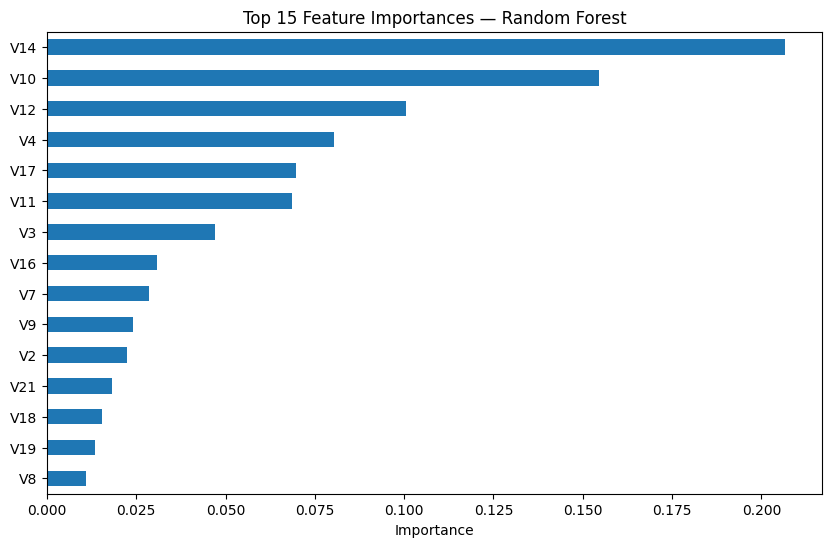

In [106]:
plt.figure(figsize=(10,6))

feature_importance.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.show()

**Random Forest feature importance analysis identified V14, V10, V12, V4, V17, and V11 as the most influential features. Several of these features also showed relatively strong correlation with the fraud target during EDA, indicating consistency between the exploratory analysis and model-based interpretation. However, feature importance does not imply causation.**

# **FINAL MODEL DECISION**

In [107]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    'Precision': [
        0.85,
        0.99,
        0.64,
        0.97
    ],
    'Recall': [
        0.59,
        0.69,
        0.79,
        0.73
    ],
    'F1': [
        0.70,
        0.81,
        0.70,
        0.83
    ]
})

results

,Model,Precision,Recall,F1
0,Logistic Regression,0.85,0.59,0.70
1,Random Forest,0.99,0.69,0.81
2,XGBoost,0.64,0.79,0.70
3,Tuned Random Forest,0.97,0.73,0.83


**Final model: Tuned Random Forest with a 0.2 decision threshold, because it provides the highest observed F1-score and improved fraud recall while maintaining high precision.**

# Conclusion

### Problem
The goal of this project was to predict whether a credit card transaction is fraudulent or legitimate.

### Key Findings
- The dataset was highly imbalanced, with approximately **99.83% legitimate** and **0.17% fraudulent** transactions.
- Missing values were not present, while duplicate records were identified and removed.
- `Amount` was strongly right-skewed, so a `log1p` transformation was created as `Amount_log`.
- Fraudulent and legitimate transactions showed different patterns in both transaction amount and time.
- `V14`, `V10`, `V12`, `V4`, `V17`, and `V11` were among the most influential features for the Random Forest model.

### Model Development
Several supervised learning approaches were evaluated, including:
- Logistic Regression
- Random Forest
- XGBoost

Random Forest produced a stronger precision-recall balance than the other tested models. Stratified cross-validation was used because of the severe class imbalance, and `RandomizedSearchCV` was used to tune the Random Forest hyperparameters.

### Final Model
The tuned Random Forest achieved:

- **Precision:** 0.97
- **Recall:** 0.73
- **F1-score:** 0.83
- **ROC-AUC:** 0.950
- **PR-AUC:** 0.820

A threshold of **0.2** improved the observed F1-score to **0.847** and recall to **0.789**, while maintaining precision of **0.915**.

### Final Takeaway
This project demonstrated an end-to-end machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, feature selection, stratified train-test splitting, preprocessing, model comparison, cross-validation, hyperparameter tuning, ensemble learning, error analysis, threshold tuning, and model interpretation.

For a production system, the classification threshold should be selected using a validation set or cross-validation rather than the final test set, based on the business cost of false positives and false negatives.